# 勇者傳說 — Overworld Character Generator V3 (T4 GPU)

Generate **front-facing standing pose** character sprites for overworld use.
These single 64×96 RGBA images are assembled into full spritesheets by `AICharacterAssembler.ts`.

**V3 improvements over V1/V2:**
- Forced cleanup of old outputs + progress files (prevents stale skip bug)
- Shorter prompts within CLIP 77-token limit
- Largest connected component extraction (scipy) to remove floating artifacts
- Quality gate: fill_ratio ≥ 15%, height_ratio ≥ 50%, auto-retry up to 3×
- 2 candidates per character, pick best by quality score
- LoRA 0.8, guidance 9.5

| Category | Count | Final Size | Gen Size | Steps |
|----------|-------|------------|----------|-------|
| Party members | 8 | 64×96 | 512×768 | 30 |
| NPC types | 5 | 64×96 | 512×768 | 28 |
| Guard base | 1 | 64×96 | 512×768 | 28 |

**Output**: `overworld_characters/` → 14 RGBA PNGs  
**Import**: `bash scripts/import_colab_assets.sh ~/Downloads/overworld_v3_output`

## 0. FORCED CLEANUP

Delete old progress files and output directory to prevent stale-skip bug.
**This cell MUST run before generation.**

In [1]:
import os, shutil, glob
from pathlib import Path

try:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

GDRIVE_BASE = Path('/content/drive/MyDrive/ai-rpg-game')
OUTPUT_BASE = GDRIVE_BASE / 'outputs' if ON_COLAB else Path('outputs')

# 1) Delete ALL old progress files matching any owc pattern
progress_patterns = [
    '_progress_owc_*.json',
    '_progress_owc_v2_*.json',
    '_progress_owc_v3_*.json',
]
deleted = 0
for pattern in progress_patterns:
    for f in OUTPUT_BASE.glob(pattern):
        f.unlink()
        deleted += 1
        print(f'  Deleted progress: {f.name}')

# 2) Delete old output directory
old_dir = OUTPUT_BASE / 'overworld_characters'
if old_dir.exists():
    shutil.rmtree(str(old_dir))
    print(f'  Deleted directory: {old_dir}')
    deleted += 1

if deleted == 0:
    print('Nothing to clean up (first run).')
else:
    print(f'\nCleaned {deleted} items. Ready for fresh generation.')

Mounted at /content/drive
Nothing to clean up (first run).


## 1. Setup

In [2]:
!pip install -q "numpy<2" scipy
!pip install -q diffusers transformers accelerate safetensors "Pillow>=10,<12" rembg onnxruntime

import gc, json, time
from pathlib import Path

MODELS_DIR = GDRIVE_BASE / 'models' if ON_COLAB else Path('models')

for d in [OUTPUT_BASE, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

import torch
if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    vram = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
    DEVICE = 'cuda'
    DTYPE = torch.float16
    print(f'GPU: {name} ({vram:.1f} GB VRAM)')
else:
    DEVICE = 'cpu'
    DTYPE = torch.bfloat16
    print('WARNING: No GPU! Generation will be very slow.')

print(f'Output: {OUTPUT_BASE}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 72.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but y

## 2. Utilities

In [3]:
import numpy as np
from scipy import ndimage

class ProgressTracker:
    """Track completed items so we can resume after interruption."""
    def __init__(self, name, base_dir):
        self.path = Path(base_dir) / f'_progress_{name}.json'
        self.done = set()
        if self.path.exists():
            try:
                self.done = set(json.loads(self.path.read_text()))
            except Exception:
                pass

    def is_done(self, key):
        return key in self.done

    def mark_done(self, key):
        self.done.add(key)
        self.path.write_text(json.dumps(sorted(self.done)))

    def summary(self, total):
        return f'{len(self.done)}/{total} done'


def free_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def print_vram(label=''):
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated() / 1024**3
        total = torch.cuda.get_device_properties(0)
        total_gb = (getattr(total, 'total_memory', None) or getattr(total, 'total_mem', 0)) / 1024**3
        print(f'VRAM {label}: {used:.1f} / {total_gb:.1f} GB')
    else:
        print(f'VRAM {label}: N/A (CPU)')


def largest_connected_component(rgba_img):
    """Extract the largest connected non-transparent region from RGBA image.
    Uses 8-connected labeling with dilation to bridge small gaps.
    Returns the cropped RGBA image of just the main figure."""
    arr = np.array(rgba_img)
    alpha = arr[:, :, 3]
    mask = alpha > 30  # threshold for non-transparent

    # Dilate slightly to bridge 1-2px gaps between parts (e.g. weapon and hand)
    struct = ndimage.generate_binary_structure(2, 2)  # 8-connected
    dilated = ndimage.binary_dilation(mask, struct, iterations=3)

    labeled, n_features = ndimage.label(dilated, structure=struct)
    if n_features <= 1:
        return rgba_img  # single component or empty

    # Find largest component
    sizes = ndimage.sum(mask, labeled, range(1, n_features + 1))
    largest_label = np.argmax(sizes) + 1

    # Create mask for largest component (use original non-dilated pixels)
    keep_mask = (labeled == largest_label) & mask

    # Zero out pixels not in largest component
    result = arr.copy()
    result[~keep_mask] = [0, 0, 0, 0]

    from PIL import Image
    return Image.fromarray(result)


def quality_score(rgba_img, target_w=64, target_h=96):
    """Score an RGBA image for quality as a character sprite.
    Returns (score, fill_ratio, height_ratio) where score = fill * height.
    fill_ratio: fraction of target area that has non-transparent pixels.
    height_ratio: fraction of target height that the figure occupies."""
    arr = np.array(rgba_img)
    alpha = arr[:, :, 3]
    mask = alpha > 30

    total_pixels = target_w * target_h
    filled_pixels = np.sum(mask)
    fill_ratio = filled_pixels / total_pixels

    # Height coverage: how much vertical space the figure uses
    rows_with_content = np.any(mask, axis=1)
    if not np.any(rows_with_content):
        return 0.0, 0.0, 0.0

    first_row = np.argmax(rows_with_content)
    last_row = len(rows_with_content) - np.argmax(rows_with_content[::-1]) - 1
    content_height = last_row - first_row + 1
    height_ratio = content_height / rgba_img.height

    score = fill_ratio * height_ratio
    return score, fill_ratio, height_ratio


# Quality thresholds
MIN_FILL_RATIO = 0.15
MIN_HEIGHT_RATIO = 0.50

print('Utilities ready (scipy LCC + quality gate)')

Utilities ready (scipy LCC + quality gate)


## 3. Prompt Data

**V3 changes:**
- Prompts are shorter (< 60 tokens each to stay within CLIP 77-token limit after prefix/suffix)
- No `style_prefix_xl` concatenation — style keywords baked into each prompt
- Negative prompt strengthened against multi-character and sprite-sheet generation

In [4]:
# Each prompt is self-contained (no prefix/suffix concat) to stay within CLIP limits.
# Format: pixel art style + character description + pose + background

NEGATIVE = 'blurry, text, watermark, signature, multiple characters, duplicate, group, sprite sheet, multiple views, multiple poses, turnaround, side view, profile, realistic photo, complex background, border, frame, grid'

PARTY = [
    {'name': 'char_hero',    'prompt': 'pixel art, single chibi character, young prince swordsman, gold circlet, crimson cape, blue armor with gold emblem, sword, standing idle front view, dark background'},
    {'name': 'char_elf',     'prompt': 'pixel art, single chibi character, elf ranger, pointed ears, blonde, green cloak, dark green leather armor, wooden bow, standing idle front view, dark background'},
    {'name': 'char_treant',  'prompt': 'pixel art, single chibi character, ancient tree sage, bark skin, dark green cape, emerald robe, wooden staff, standing idle front view, dark background'},
    {'name': 'char_beast',   'prompt': 'pixel art, single chibi character, fierce beast monk, muscular, red bandana, orange tunic, bare fists, standing idle front view, dark background'},
    {'name': 'char_merfolk', 'prompt': 'pixel art, single chibi character, ocean priestess, silver tiara, blue cape, white robe with water motifs, crystal staff, standing idle front view, dark background'},
    {'name': 'char_giant',   'prompt': 'pixel art, single chibi character, armored war machine, metal helmet, dark blue cape, heavy steel plate armor, war hammer, standing idle front view, dark background'},
    {'name': 'char_dwarf',   'prompt': 'pixel art, single chibi character, hooded assassin, brown cloak, dark leather armor with belts, twin daggers, standing idle front view, dark background'},
    {'name': 'char_undead',  'prompt': 'pixel art, single chibi character, dark sorcerer, purple wizard hat, violet cape, purple robe with arcane symbols, dark staff, standing idle front view, dark background'},
]

NPCS = [
    {'name': 'char_npc_shop',  'prompt': 'pixel art, single chibi character, plump merchant, leather apron, brown tunic, coin pouch, warm smile, standing idle front view, dark background'},
    {'name': 'char_npc_quest', 'prompt': 'pixel art, single chibi character, adventurer quest giver, green cloak, scroll at belt, explorer hat, standing idle front view, dark background'},
    {'name': 'char_npc_save',  'prompt': 'pixel art, single chibi character, holy priest, white robes with gold trim, prayer beads, gentle expression, standing idle front view, dark background'},
    {'name': 'char_npc_info',  'prompt': 'pixel art, single chibi character, wise old elder, long white beard, walking cane, blue robe, standing idle front view, dark background'},
    {'name': 'char_npc_inn',   'prompt': 'pixel art, single chibi character, cheerful innkeeper, stout build, white apron, holding mug, hearty smile, standing idle front view, dark background'},
]

GUARD = [
    {'name': 'char_guard', 'prompt': 'pixel art, single chibi character, town guard soldier, chain mail armor, iron helmet, spear, shield on back, standing at attention front view, dark background'},
]

total = len(PARTY) + len(NPCS) + len(GUARD)
print(f'Total characters to generate: {total}')
print(f'Negative prompt ({len(NEGATIVE.split(","))} terms): {NEGATIVE[:80]}...')

Total characters to generate: 14
Negative prompt (18 terms): blurry, text, watermark, signature, multiple characters, duplicate, group, sprit...


## 4. Load SDXL Pipeline + LoRA

In [5]:
from diffusers import StableDiffusionXLPipeline, DPMSolverMultistepScheduler

print_vram('before load')

MODEL_ID = 'stabilityai/stable-diffusion-xl-base-1.0'
LORA_ID = 'nerijs/pixel-art-xl'
LORA_WEIGHT = 0.8  # V3: lower from 0.9 to reduce over-pixelation artifacts

cached = MODELS_DIR / 'sdxl-base-fp16'
if cached.exists() and (cached / 'model_index.json').exists():
    print(f'Loading SDXL from cache: {cached}')
    pipe = StableDiffusionXLPipeline.from_pretrained(
        str(cached), torch_dtype=DTYPE, use_safetensors=True)
else:
    print(f'Downloading SDXL from HuggingFace...')
    pipe = StableDiffusionXLPipeline.from_pretrained(
        MODEL_ID, torch_dtype=DTYPE, use_safetensors=True, variant='fp16')
    if ON_COLAB:
        try:
            print(f'Caching to Drive: {cached}')
            pipe.save_pretrained(str(cached))
        except Exception as e:
            print(f'[warn] Drive cache failed: {e}')

pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type='dpmsolver++',
    use_karras_sigmas=True)

print(f'Loading LoRA: {LORA_ID} (weight={LORA_WEIGHT})')
pipe.load_lora_weights(LORA_ID)
pipe.fuse_lora(lora_scale=LORA_WEIGHT)

pipe = pipe.to(DEVICE)
pipe.enable_attention_slicing()

print_vram('after load')
print('Pipeline ready!')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


VRAM before load: 0.0 / 14.6 GB
Loading SDXL from cache: /content/drive/MyDrive/ai-rpg-game/models/sdxl-base-fp16


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:03<?, ?it/s]

Loading LoRA: nerijs/pixel-art-xl (weight=0.8)


pixel-art-xl.safetensors:   0%|          | 0.00/171M [00:00<?, ?B/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


VRAM after load: 6.7 / 14.6 GB
Pipeline ready!


## 5. Background Removal + Post-Processing

V3 pipeline per character:
1. Generate at 512×768
2. RMBG/rembg background removal → RGBA
3. Largest connected component extraction (scipy)
4. Crop to bounding box
5. Resize to 64×96 with NEAREST (pixel-art crisp)
6. Quality gate check (fill ≥ 15%, height ≥ 50%)

In [6]:
from PIL import Image

TARGET_W = 64
TARGET_H = 96

_rembg_session = None

def remove_background(image):
    """Remove background using rembg (u2net). Returns RGBA."""
    global _rembg_session
    try:
        from rembg import remove, new_session
        if _rembg_session is None:
            _rembg_session = new_session('u2net')
        return remove(image, session=_rembg_session)
    except Exception as e:
        print(f'[warn] rembg failed: {e}')
        return image.convert('RGBA')


def postprocess(image):
    """Full pipeline: rembg → LCC → crop → resize → quality check.
    Returns (final_image, score, fill_ratio, height_ratio)."""
    # 1. Background removal
    rgba = remove_background(image)

    # 2. Largest connected component (remove floating artifacts)
    rgba = largest_connected_component(rgba)

    # 3. Crop to bounding box
    bbox = rgba.getbbox()
    if bbox:
        rgba = rgba.crop(bbox)

    # 4. Fit into 64x96, maintaining aspect ratio, bottom-aligned
    w, h = rgba.size
    if w == 0 or h == 0:
        canvas = Image.new('RGBA', (TARGET_W, TARGET_H), (0, 0, 0, 0))
        return canvas, 0.0, 0.0, 0.0

    scale = min(TARGET_W / w, TARGET_H / h)
    nw, nh = max(1, int(w * scale)), max(1, int(h * scale))
    rgba = rgba.resize((nw, nh), Image.NEAREST)

    # Center horizontally, bottom-align vertically (feet at bottom edge)
    canvas = Image.new('RGBA', (TARGET_W, TARGET_H), (0, 0, 0, 0))
    paste_x = (TARGET_W - nw) // 2
    paste_y = TARGET_H - nh
    canvas.paste(rgba, (paste_x, paste_y), rgba)

    # 5. Quality score
    score, fill_r, height_r = quality_score(canvas, TARGET_W, TARGET_H)
    return canvas, score, fill_r, height_r


NUM_CANDIDATES = 2
MAX_RETRIES = 3

def generate_one(entry, out_dir, tracker, steps=30, guidance=9.5):
    """Generate character with quality gate and candidate selection."""
    name = entry['name']
    prompt = entry['prompt']
    out_path = out_dir / f'{name}.png'

    if tracker.is_done(name) and out_path.exists():
        print(f'  [skip] {name}')
        return False

    print(f'  [gen] {name} ({steps} steps, guidance={guidance}, {NUM_CANDIDATES} candidates)')
    t0 = time.time()

    best_img = None
    best_score = -1
    attempt = 0

    while attempt < MAX_RETRIES:
        candidates = []
        for c in range(NUM_CANDIDATES):
            seed = int(time.time() * 1000) % (2**32) + attempt * 100 + c
            gen = torch.Generator(device=DEVICE).manual_seed(seed)

            result = pipe(
                prompt=prompt, negative_prompt=NEGATIVE,
                width=512, height=768,
                num_inference_steps=steps, guidance_scale=guidance,
                generator=gen,
            )
            raw = result.images[0]
            img, score, fill_r, height_r = postprocess(raw)
            candidates.append((img, score, fill_r, height_r, seed))
            print(f'        candidate {c}: score={score:.3f} fill={fill_r:.2f} height={height_r:.2f} seed={seed}')

        # Pick best candidate
        candidates.sort(key=lambda x: x[1], reverse=True)
        top = candidates[0]

        # Quality gate
        if top[2] >= MIN_FILL_RATIO and top[3] >= MIN_HEIGHT_RATIO:
            best_img = top[0]
            best_score = top[1]
            print(f'        PASS: score={best_score:.3f}')
            break
        else:
            attempt += 1
            print(f'        FAIL quality gate (fill={top[2]:.2f}<{MIN_FILL_RATIO} or height={top[3]:.2f}<{MIN_HEIGHT_RATIO}), retry {attempt}/{MAX_RETRIES}')
            # Keep best so far in case all retries fail
            if top[1] > best_score:
                best_img = top[0]
                best_score = top[1]
            free_vram()

    if best_img is None:
        print(f'        WARNING: all retries failed for {name}, using best attempt')
        best_img = candidates[0][0] if candidates else Image.new('RGBA', (TARGET_W, TARGET_H), (0, 0, 0, 0))

    best_img.save(str(out_path), 'PNG')
    kb = out_path.stat().st_size / 1024
    print(f'        saved: {name}.png ({kb:.0f} KB, {time.time()-t0:.1f}s)')
    tracker.mark_done(name)
    free_vram()
    return True

print('Generation pipeline ready (2 candidates, 3 retries, quality gate)')

Generation pipeline ready (2 candidates, 3 retries, quality gate)


## 6. Test: Generate 1 Character

Quick visual check before batch generation.

Prompt: pixel art, single chibi character, young prince swordsman, gold circlet, crimson cape, blue armor with gold emblem, sword, standing idle front view, dark background
Negative: blurry, text, watermark, signature, multiple characters, duplicate, group, sprit...


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


Raw 512x768:


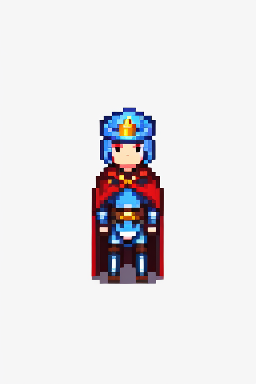

  0%|                                               | 0.00/176M [00:00<?, ?B/s]


Processed 64x96 (shown at 6x):
Quality: score=0.476, fill=0.50, height=0.96
Gate: PASS


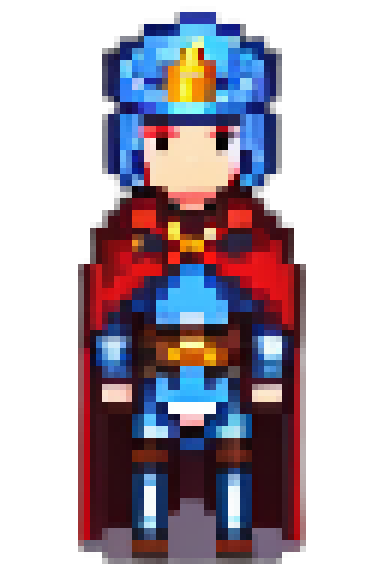

In [7]:
from IPython.display import display

test_entry = PARTY[0]  # hero
print(f'Prompt: {test_entry["prompt"]}')
print(f'Negative: {NEGATIVE[:80]}...')

seed = 42
gen = torch.Generator(device=DEVICE).manual_seed(seed)
result = pipe(prompt=test_entry['prompt'], negative_prompt=NEGATIVE,
              width=512, height=768, num_inference_steps=30, guidance_scale=9.5,
              generator=gen)
print('Raw 512x768:')
display(result.images[0].resize((256, 384), Image.NEAREST))

processed, score, fill_r, height_r = postprocess(result.images[0])
zoomed = processed.resize((TARGET_W * 6, TARGET_H * 6), Image.NEAREST)
print(f'\nProcessed {TARGET_W}x{TARGET_H} (shown at 6x):')
print(f'Quality: score={score:.3f}, fill={fill_r:.2f}, height={height_r:.2f}')
gate = 'PASS' if fill_r >= MIN_FILL_RATIO and height_r >= MIN_HEIGHT_RATIO else 'FAIL'
print(f'Gate: {gate}')
display(zoomed)
free_vram()

## 7. Generate Party Members (8 sprites)

~15-25s per character (2 candidates × 30 steps each)

In [8]:
out_dir = OUTPUT_BASE / 'overworld_characters'
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('owc_v3_party', OUTPUT_BASE)
remaining = sum(1 for e in PARTY if not tracker.is_done(e['name']))
print(f'\nParty: {len(PARTY)} total, {remaining} to generate')

for i, entry in enumerate(PARTY):
    print(f'\n[{i+1}/{len(PARTY)}] {tracker.summary(len(PARTY))}')
    generate_one(entry, out_dir, tracker, steps=30, guidance=9.5)

print(f'\nParty generation complete!')


Party: 8 total, 8 to generate

[1/8] 0/8 done
  [gen] char_hero (30 steps, guidance=9.5, 2 candidates)


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


        candidate 0: score=0.517 fill=0.56 height=0.92 seed=3509347015


  0%|          | 0/30 [00:00<?, ?it/s]

...

        candidate 1: score=0.510 fill=0.52 height=0.98 seed=3509558685
        PASS: score=0.510
        saved: char_dwarf.png (8 KB, 31.6s)

[8/8] 7/8 done
  [gen] char_undead (30 steps, guidance=9.5, 2 candidates)


  0%|          | 0/30 [00:00<?, ?it/s]

        candidate 0: score=0.665 fill=0.67 height=1.00 seed=3509575072


  0%|          | 0/30 [00:00<?, ?it/s]

        candidate 1: score=0.446 fill=0.46 height=0.98 seed=3509591365
        PASS: score=0.665
        saved: char_undead.png (10 KB, 32.9s)

Party generation complete!


## 8. Generate NPCs (5 sprites)

In [9]:
out_dir = OUTPUT_BASE / 'overworld_characters'
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('owc_v3_npcs', OUTPUT_BASE)
remaining = sum(1 for e in NPCS if not tracker.is_done(e['name']))
print(f'\nNPCs: {len(NPCS)} total, {remaining} to generate')

for i, entry in enumerate(NPCS):
    print(f'\n[{i+1}/{len(NPCS)}] {tracker.summary(len(NPCS))}')
    generate_one(entry, out_dir, tracker, steps=28, guidance=9.5)

print(f'\nNPC generation complete!')


NPCs: 5 total, 5 to generate

[1/5] 0/5 done
  [gen] char_npc_shop (28 steps, guidance=9.5, 2 candidates)


  0%|          | 0/28 [00:00<?, ?it/s]

        candidate 0: score=0.571 fill=0.58 height=0.98 seed=3509608684


  0%|          | 0/28 [00:00<?, ?it/s]

        candidate 1: score=0.519 fill=0.54 height=0.97 seed=3509623813
        PASS: score=0.571
        saved: char_npc_shop.png (9 KB, 30.2s)

[2/5] 1/5 done
  [gen] char_npc_quest (28 steps, guidance=9.5, 2 candidates)


...

        candidate 1: score=0.482 fill=0.49 height=0.98 seed=3509715619
        PASS: score=0.486
        saved: char_npc_info.png (10 KB, 30.4s)

[5/5] 4/5 done
  [gen] char_npc_inn (28 steps, guidance=9.5, 2 candidates)


  0%|          | 0/28 [00:00<?, ?it/s]

        candidate 0: score=0.449 fill=0.45 height=0.99 seed=3509731526


  0%|          | 0/28 [00:00<?, ?it/s]

        candidate 1: score=0.330 fill=0.43 height=0.77 seed=3509747052
        PASS: score=0.449
        saved: char_npc_inn.png (8 KB, 31.0s)

NPC generation complete!


## 9. Generate Guard Base (1 sprite)

In [10]:
out_dir = OUTPUT_BASE / 'overworld_characters'
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('owc_v3_guard', OUTPUT_BASE)
remaining = sum(1 for e in GUARD if not tracker.is_done(e['name']))
print(f'\nGuard: {len(GUARD)} total, {remaining} to generate')

for i, entry in enumerate(GUARD):
    print(f'\n[{i+1}/{len(GUARD)}] {tracker.summary(len(GUARD))}')
    generate_one(entry, out_dir, tracker, steps=28, guidance=9.5)

print(f'\nGuard generation complete!')


Guard: 1 total, 1 to generate

[1/1] 0/1 done
  [gen] char_guard (28 steps, guidance=9.5, 2 candidates)


  0%|          | 0/28 [00:00<?, ?it/s]

        candidate 0: score=0.503 fill=0.51 height=0.98 seed=3509763072


  0%|          | 0/28 [00:00<?, ?it/s]

        candidate 1: score=0.618 fill=0.62 height=1.00 seed=3509778128
        PASS: score=0.618
        saved: char_guard.png (10 KB, 30.2s)

Guard generation complete!


## 10. Quality Review — All Characters

Quality report for 14 sprites:

  char_beast            fill=0.65  height=0.97  score=0.630  PASS
  char_dwarf            fill=0.52  height=0.98  score=0.510  PASS
  char_elf              fill=0.44  height=0.99  score=0.434  PASS
  char_giant            fill=0.72  height=0.98  score=0.706  PASS
  char_guard            fill=0.62  height=1.00  score=0.618  PASS
  char_hero             fill=0.75  height=1.00  score=0.755  PASS
  char_merfolk          fill=0.68  height=0.99  score=0.671  PASS
  char_npc_info         fill=0.51  height=0.96  score=0.486  PASS
  char_npc_inn          fill=0.45  height=0.99  score=0.449  PASS
  char_npc_quest        fill=0.54  height=0.99  score=0.533  PASS
  char_npc_save         fill=0.74  height=0.97  score=0.713  PASS
  char_npc_shop         fill=0.58  height=0.98  score=0.571  PASS
  char_treant           fill=0.50  height=0.98  score=0.494  PASS
  char_undead           fill=0.67  height=1.00  score=0.665  PASS


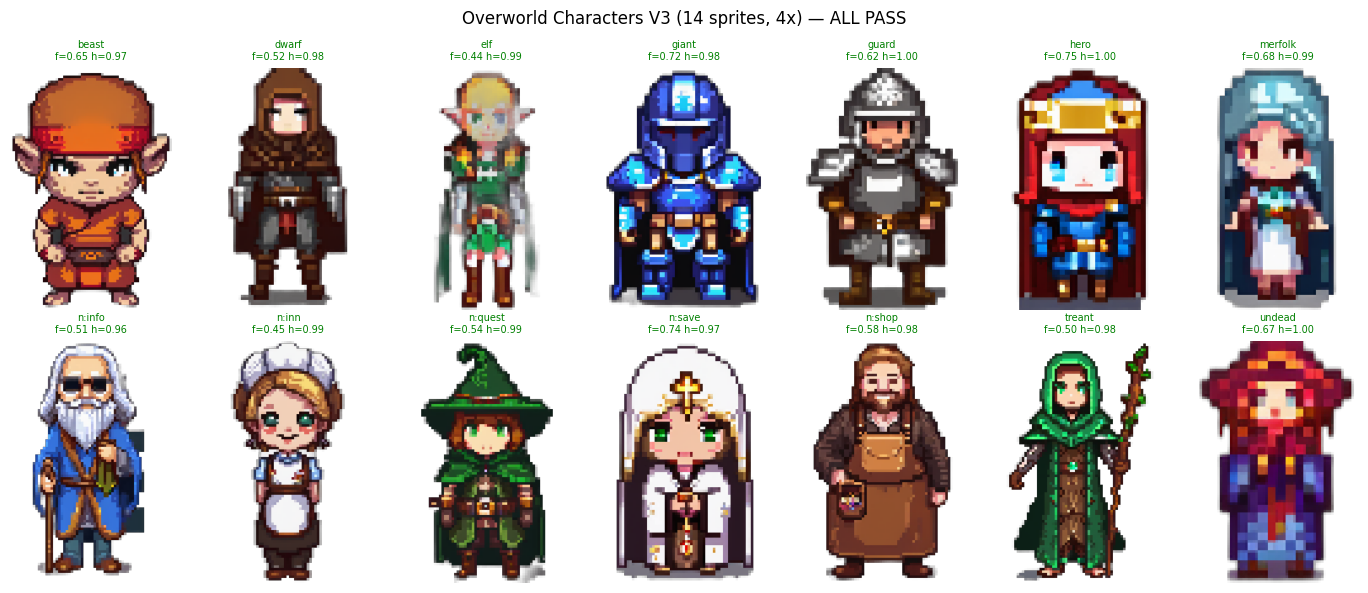


 All 14 sprites passed quality gate!


In [11]:
import matplotlib.pyplot as plt

out_dir = OUTPUT_BASE / 'overworld_characters'
pngs = sorted(out_dir.glob('*.png'))
pngs = [p for p in pngs if not p.stem.startswith('_')]

cols = 7
rows = (len(pngs) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 3))
if rows == 1:
    axes = [axes]
for ax_row in axes:
    for ax in (ax_row if hasattr(ax_row, '__iter__') else [ax_row]):
        ax.axis('off')

print(f'Quality report for {len(pngs)} sprites:\n')
all_pass = True
for i, png in enumerate(pngs):
    r, c = i // cols, i % cols
    ax = axes[r][c] if rows > 1 else axes[0][c]
    img = Image.open(png)

    # Quality check
    score, fill_r, height_r = quality_score(img, TARGET_W, TARGET_H)
    gate = 'PASS' if fill_r >= MIN_FILL_RATIO and height_r >= MIN_HEIGHT_RATIO else 'FAIL'
    if gate == 'FAIL':
        all_pass = False

    # Show at 4x for visibility
    img_zoom = img.resize((64 * 4, 96 * 4), Image.NEAREST)
    ax.imshow(img_zoom)
    label = png.stem.replace('char_', '').replace('npc_', 'n:')
    color = 'green' if gate == 'PASS' else 'red'
    ax.set_title(f'{label}\nf={fill_r:.2f} h={height_r:.2f}', fontsize=7, color=color)

    print(f'  {png.stem:20s}  fill={fill_r:.2f}  height={height_r:.2f}  score={score:.3f}  {gate}')

status = 'ALL PASS' if all_pass else 'SOME FAILED'
plt.suptitle(f'Overworld Characters V3 ({len(pngs)} sprites, 4x) — {status}', fontsize=12)
plt.tight_layout()
plt.show()

if all_pass:
    print(f'\n All {len(pngs)} sprites passed quality gate!')
else:
    print(f'\n WARNING: Some sprites failed quality gate. Re-run failed cells or adjust prompts.')

## 11. Export + Download

After downloading, import with:
```bash
bash scripts/import_colab_assets.sh ~/Downloads/overworld_v3_output
bash scripts/force_restart_frontend.sh
```

In [12]:
import shutil

# Verify output
d = OUTPUT_BASE / 'overworld_characters'
if d.exists():
    keys = sorted(f.stem for f in d.glob('*.png') if not f.stem.startswith('_'))
    print(f'overworld_characters: {len(keys)} sprites')
    for k in keys:
        print(f'  {k}')
else:
    print('ERROR: No output directory found!')

zip_path = '/content/overworld_v3_output'
shutil.make_archive(zip_path, 'zip', str(OUTPUT_BASE))
print(f'\nZip: {os.path.getsize(zip_path + ".zip") / 1024:.1f} KB')

if ON_COLAB:
    from google.colab import files
    files.download(f'{zip_path}.zip')
else:
    print(f'Download: {zip_path}.zip')

overworld_characters: 14 sprites
  char_beast
  char_dwarf
  char_elf
  char_giant
  char_guard
  char_hero
  char_merfolk
  char_npc_info
  char_npc_inn
  char_npc_quest
  char_npc_save
  char_npc_shop
  char_treant
  char_undead

Zip: 44006.5 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>